<a href="https://www.kaggle.com/code/sonawanelalitsunil/rainfall-prediction-ml-86?scriptVersionId=256245044" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/rainfall-prediction-dataset-cleaned-weatheraus/weatherAUS_rainfall_prediction_dataset_cleaned.csv


## Title: 
Rainfall Prediction Dataset (Cleaned WeatherAUS)

## Description:
The Rainfall Prediction Dataset (Cleaned WeatherAUS) is a refined version of the original Australian weather dataset, curated for machine learning and data analysis tasks. It contains daily meteorological observations such as temperature, humidity, wind speed, evaporation, sunshine hours, and pressure levels, along with a target variable indicating whether it will rain the next day (RainTomorrow). The dataset has undergone cleaning processes like handling missing values, correcting inconsistencies, and standardizing formats, making it well-suited for predictive modeling, classification tasks, and statistical analysis.

It is widely used for:

Rainfall prediction modeling (binary classification: rain/no rain)

Exploratory data analysis (EDA) on weather trends in Australia

Feature engineering for time-series and environmental data

Teaching and benchmarking machine learning algorithms

## Import dataset

In [2]:
df = pd.read_csv("/kaggle/input/rainfall-prediction-dataset-cleaned-weatheraus/weatherAUS_rainfall_prediction_dataset_cleaned.csv")

In [3]:
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2010-04-30,Adelaide,10.8,21.2,0.0,1.8,6.60,ENE,22.0,ENE,...,66.0,48.0,1028.4,1024.7,4.45,4.51,15.7,21.0,No,No
1,2014-07-22,Adelaide,3.7,19.0,0.0,1.4,7.61,N,24.0,N,...,75.0,32.0,1024.2,1021.1,4.45,4.51,9.6,18.5,No,No
2,2014-07-23,Adelaide,9.6,15.8,0.0,2.6,7.61,NE,52.0,NNE,...,35.0,51.0,1017.9,1011.5,4.45,4.51,14.7,15.4,No,Yes
3,2014-07-24,Adelaide,10.1,15.5,16.6,0.8,7.61,NNE,50.0,NW,...,96.0,80.0,1007.4,1008.0,4.45,4.51,11.2,14.0,Yes,Yes
4,2014-07-25,Adelaide,11.2,16.2,1.8,0.6,7.61,NW,30.0,WNW,...,89.0,70.0,1018.4,1019.2,4.45,4.51,13.0,15.3,Yes,Yes


In [4]:
df.tail()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
145455,2012-01-14,Woomera,16.8,31.9,0.0,27.00,7.61,SSE,44.0,SE,...,51.0,17.0,1017.3,1014.2,0.0,4.51,20.2,29.5,No,No
145456,2012-01-15,Woomera,17.0,33.5,0.0,12.40,12.70,SSE,43.0,ESE,...,38.0,12.0,1015.2,1011.8,0.0,0.00,22.2,32.0,No,No
145457,2012-01-16,Woomera,18.9,38.8,0.0,12.00,12.40,N,41.0,ENE,...,10.0,5.0,1012.0,1008.7,0.0,0.00,27.6,37.9,No,No
145458,2012-01-18,Woomera,23.5,38.3,0.0,18.20,13.00,SSE,50.0,SSE,...,54.0,22.0,1013.2,1011.3,1.0,1.00,25.1,35.4,No,No
145459,2017-01-10,Woomera,21.7,34.5,0.0,5.47,7.61,SE,37.0,SSE,...,71.0,36.0,1010.5,1008.8,6.0,2.00,24.0,33.5,No,No


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        145460 non-null  float64
 3   MaxTemp        145460 non-null  float64
 4   Rainfall       145460 non-null  float64
 5   Evaporation    145460 non-null  float64
 6   Sunshine       145460 non-null  float64
 7   WindGustDir    145460 non-null  object 
 8   WindGustSpeed  145460 non-null  float64
 9   WindDir9am     145460 non-null  object 
 10  WindDir3pm     145460 non-null  object 
 11  WindSpeed9am   145460 non-null  float64
 12  WindSpeed3pm   145460 non-null  float64
 13  Humidity9am    145460 non-null  float64
 14  Humidity3pm    145460 non-null  float64
 15  Pressure9am    145460 non-null  float64
 16  Pressure3pm    145460 non-null  float64
 17  Cloud9am       145460 non-nul

In [6]:
df.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000
mean,12.193993,23.221337,2.360898,5.468995,7.610612,40.035567,14.043384,18.662601,68.880816,51.539143,1017.649946,1015.256314,4.448437,4.509959,16.990624,21.683306
std,6.365750,7.088124,8.382488,3.161541,2.729486,13.118253,8.861059,8.716581,18.854765,20.471189,6.728467,6.663973,2.265605,2.092954,6.449221,6.850057
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.500000,977.100000,0.000000,0.000000,-7.200000,-5.400000
25%,7.700000,18.000000,0.000000,4.000000,7.610000,31.000000,7.000000,13.000000,57.000000,37.000000,1013.500000,1011.100000,3.000000,4.000000,12.300000,16.700000
50%,12.100000,22.700000,0.000000,5.470000,7.610000,39.000000,13.000000,18.660000,69.000000,51.540000,1017.650000,1015.260000,4.450000,4.510000,16.800000,21.400000
75%,16.800000,28.200000,1.000000,5.470000,8.700000,46.000000,19.000000,24.000000,83.000000,65.000000,1021.800000,1019.400000,6.000000,6.000000,21.500000,26.200000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.000000,1039.600000,9.000000,9.000000,40.200000,46.700000


In [7]:
df.dtypes

Date              object
Location          object
MinTemp          float64
MaxTemp          float64
Rainfall         float64
Evaporation      float64
Sunshine         float64
WindGustDir       object
WindGustSpeed    float64
WindDir9am        object
WindDir3pm        object
WindSpeed9am     float64
WindSpeed3pm     float64
Humidity9am      float64
Humidity3pm      float64
Pressure9am      float64
Pressure3pm      float64
Cloud9am         float64
Cloud3pm         float64
Temp9am          float64
Temp3pm          float64
RainToday         object
RainTomorrow      object
dtype: object

In [8]:
df.shape

(145460, 23)

In [9]:
df.isnull().sum()

Date             0
Location         0
MinTemp          0
MaxTemp          0
Rainfall         0
Evaporation      0
Sunshine         0
WindGustDir      0
WindGustSpeed    0
WindDir9am       0
WindDir3pm       0
WindSpeed9am     0
WindSpeed3pm     0
Humidity9am      0
Humidity3pm      0
Pressure9am      0
Pressure3pm      0
Cloud9am         0
Cloud3pm         0
Temp9am          0
Temp3pm          0
RainToday        0
RainTomorrow     0
dtype: int64

In [10]:
df.duplicated().sum()

0

In [11]:
df.columns

Index(['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation',
       'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'RainToday', 'RainTomorrow'],
      dtype='object')

## Data visualizations

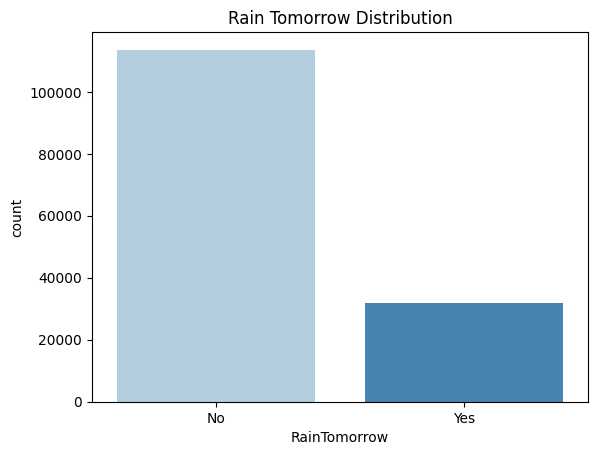

In [12]:
sns.countplot(x='RainTomorrow', data=df, palette="Blues")
plt.title("Rain Tomorrow Distribution")
plt.show()


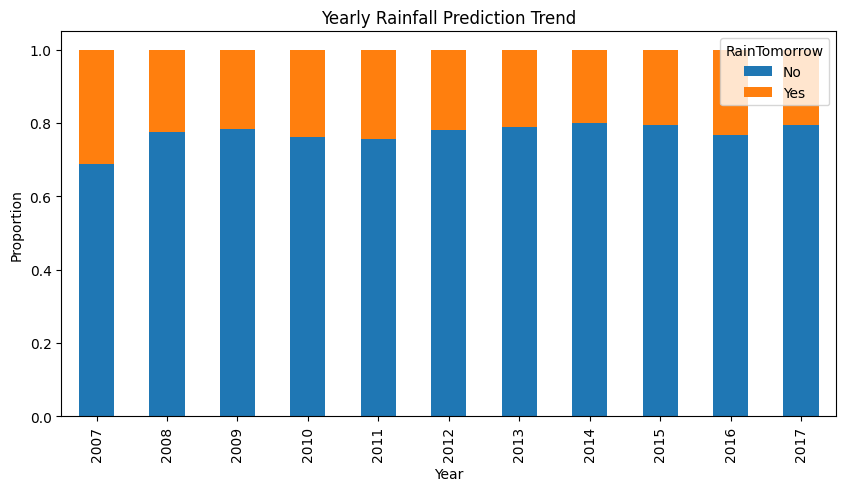

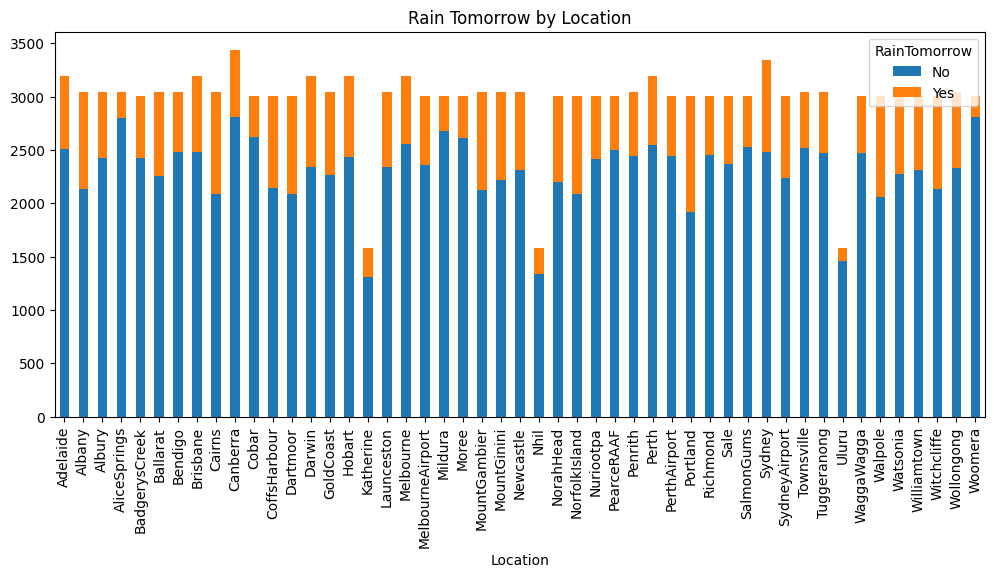

In [13]:
df['Year'] = pd.to_datetime(df['Date']).dt.year
rain_per_year = df.groupby('Year')['RainTomorrow'].value_counts(normalize=True).unstack()

rain_per_year.plot(kind="bar", stacked=True, figsize=(10,5))
plt.title("Yearly Rainfall Prediction Trend")
plt.ylabel("Proportion")
plt.show()

top_rainy = df.groupby("Location")['RainTomorrow'].value_counts().unstack().fillna(0)
top_rainy.plot(kind="bar", stacked=True, figsize=(12,5))
plt.title("Rain Tomorrow by Location")
plt.show()


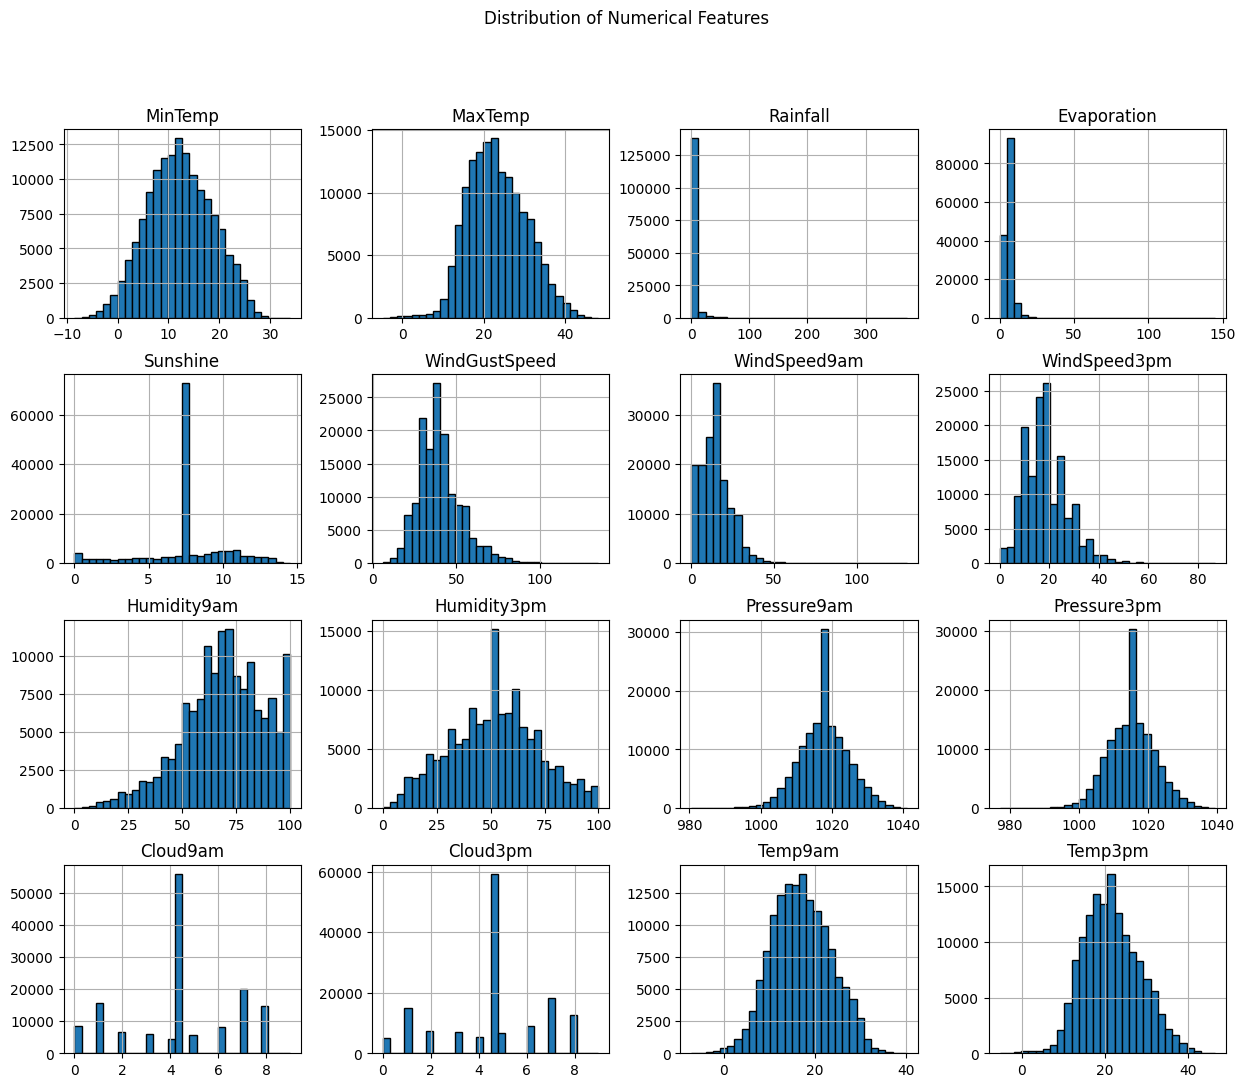

In [14]:
num_cols = ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
            'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm',
            'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm',
            'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm']

df[num_cols].hist(figsize=(15,12), bins=30, edgecolor="black")
plt.suptitle("Distribution of Numerical Features")
plt.show()


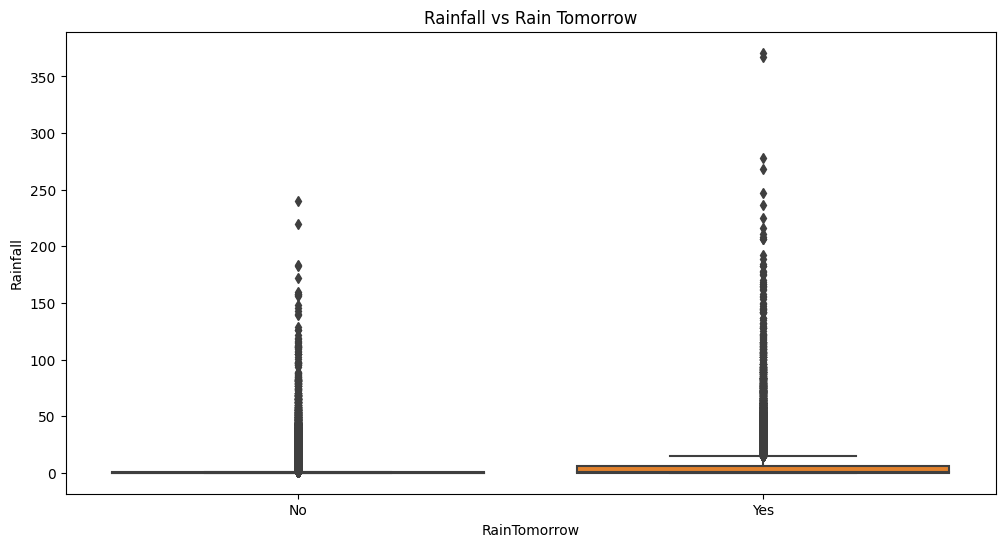

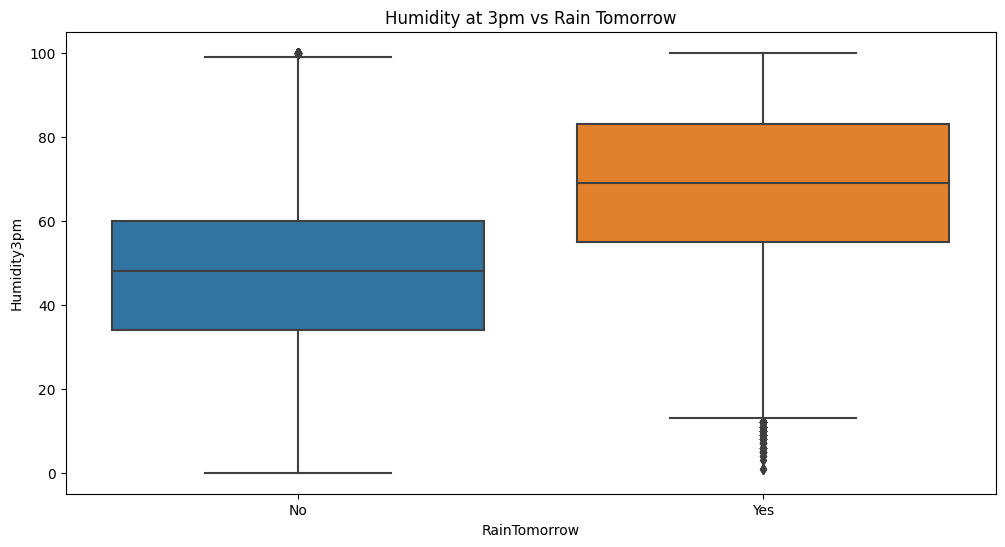

In [15]:
plt.figure(figsize=(12,6))
sns.boxplot(x='RainTomorrow', y='Rainfall', data=df)
plt.title("Rainfall vs Rain Tomorrow")
plt.show()

plt.figure(figsize=(12,6))
sns.boxplot(x='RainTomorrow', y='Humidity3pm', data=df)
plt.title("Humidity at 3pm vs Rain Tomorrow")
plt.show()


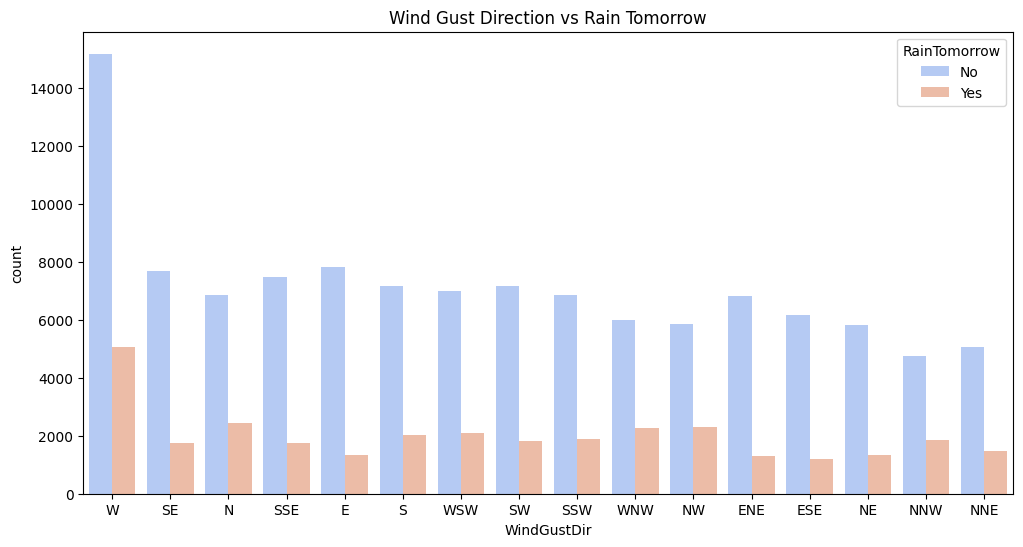

In [16]:
plt.figure(figsize=(12,6))
sns.countplot(x='WindGustDir', hue='RainTomorrow', data=df, order=df['WindGustDir'].value_counts().index, palette="coolwarm")
plt.title("Wind Gust Direction vs Rain Tomorrow")
plt.show()


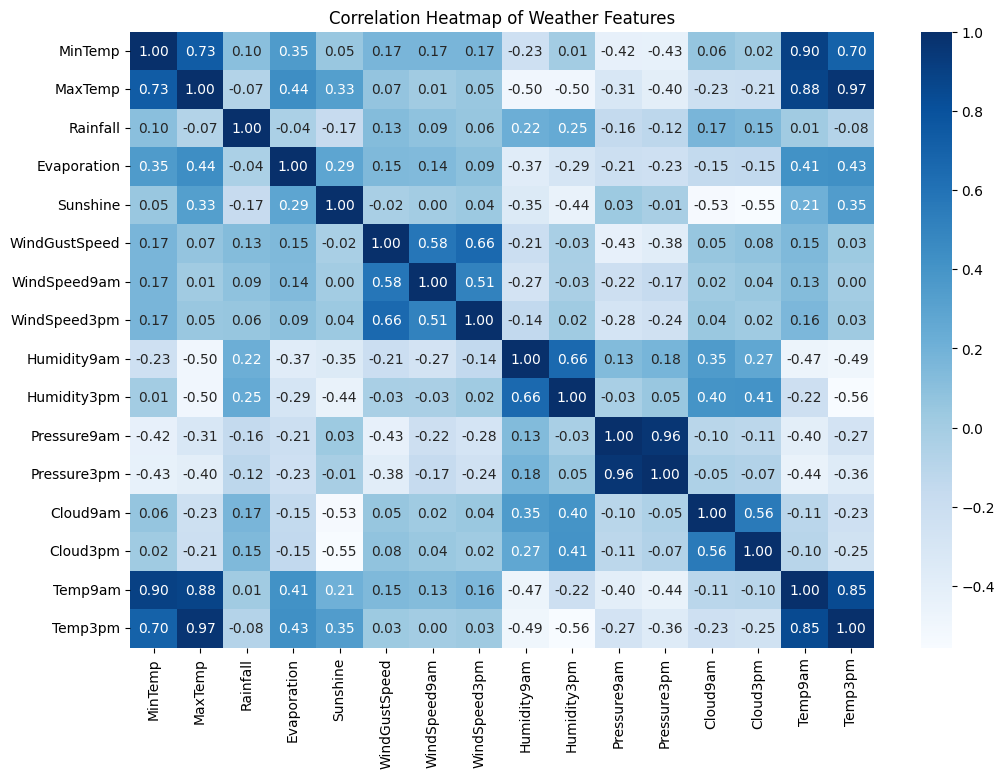

In [17]:
plt.figure(figsize=(12,8))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues")
plt.title("Correlation Heatmap of Weather Features")
plt.show()


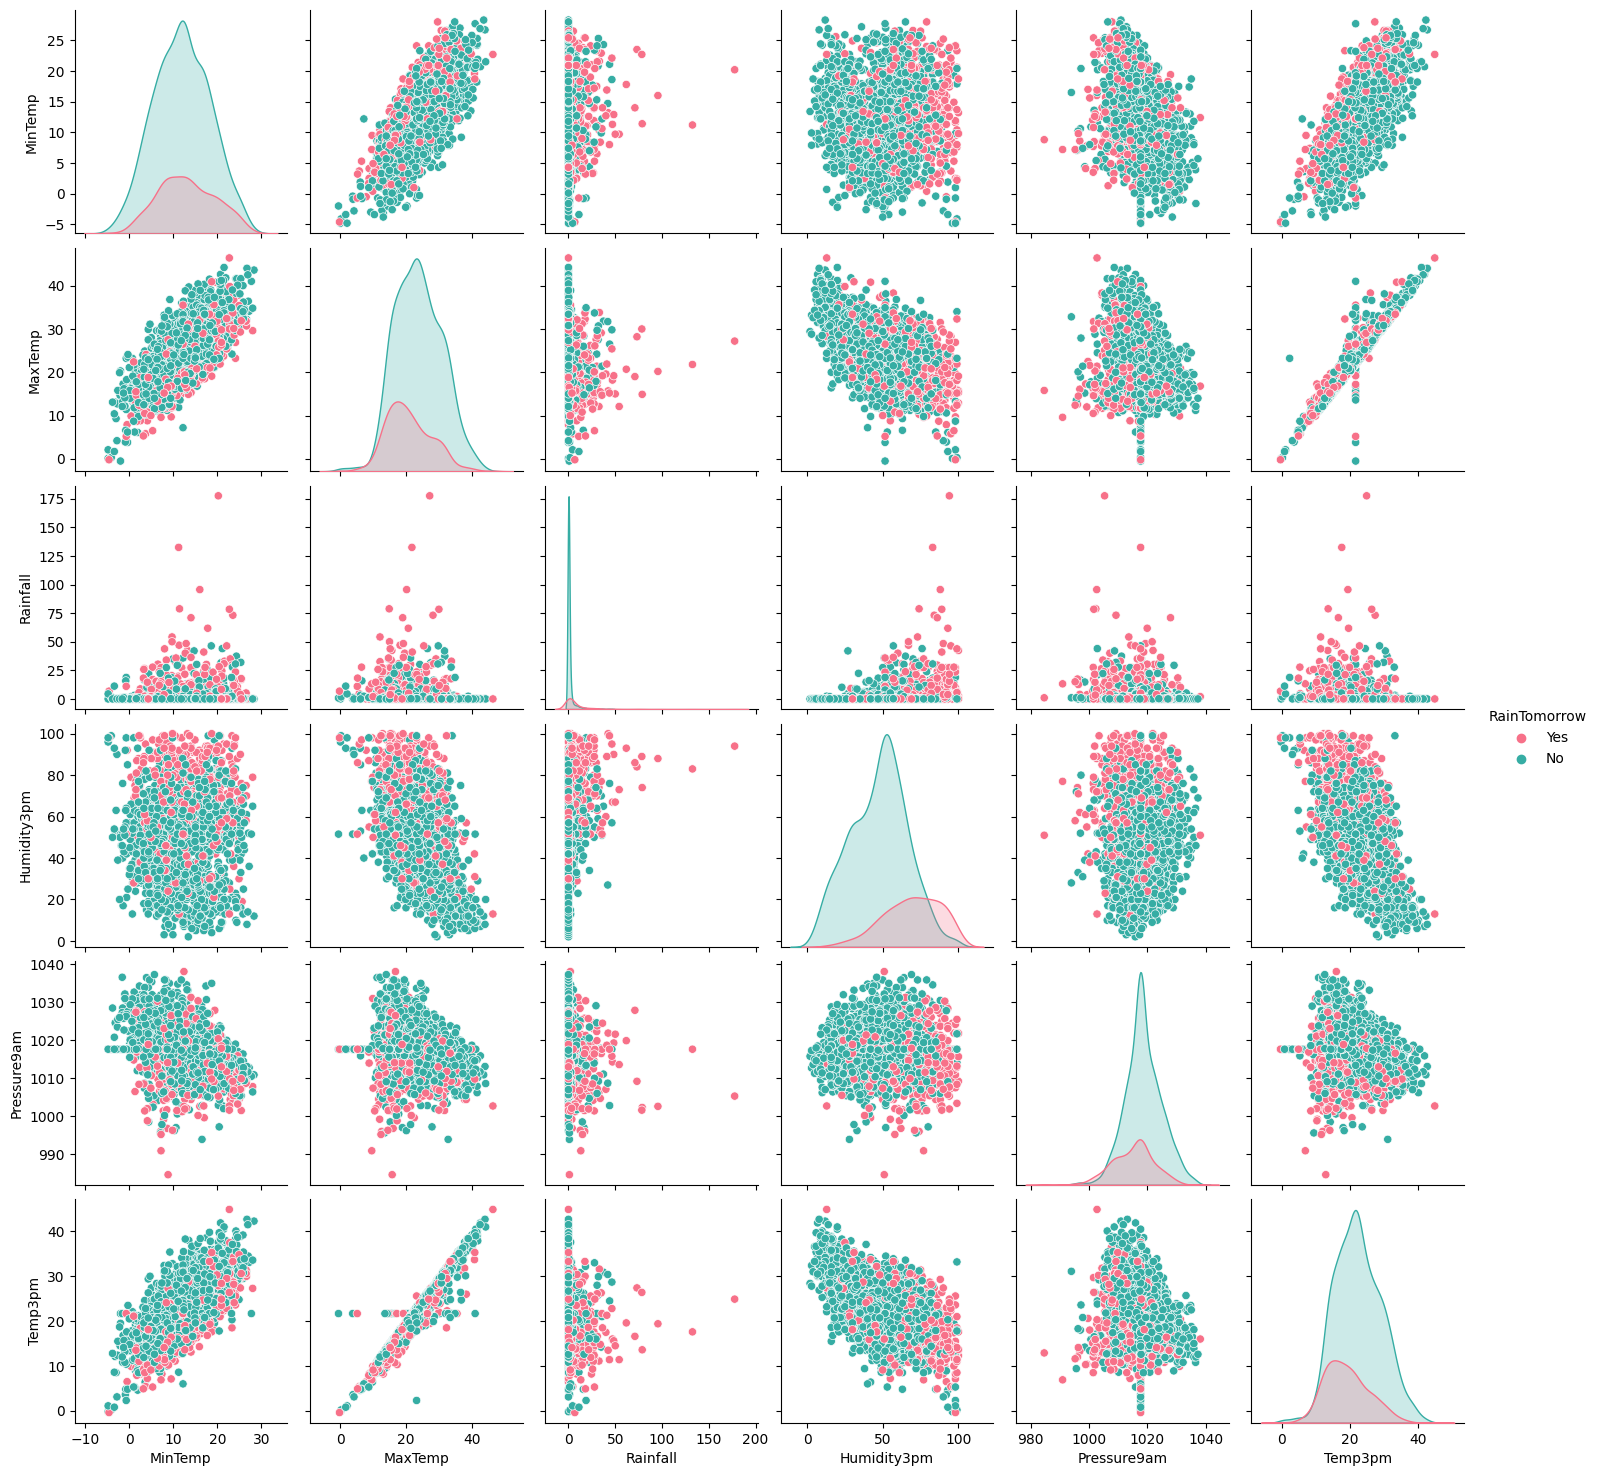

In [18]:
sample_df = df.sample(2000, random_state=42)  # downsample for speed
sns.pairplot(sample_df[['MinTemp','MaxTemp','Rainfall','Humidity3pm','Pressure9am','Temp3pm','RainTomorrow']], hue="RainTomorrow", palette="husl")
plt.show()


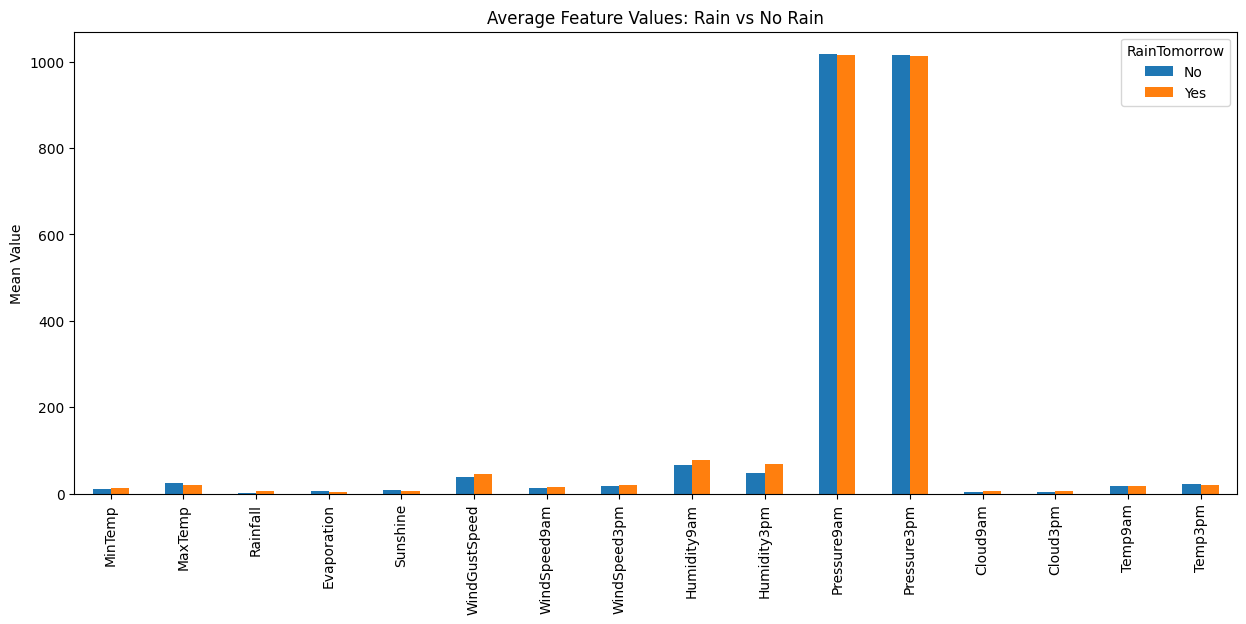

In [19]:
rain_mean = df.groupby("RainTomorrow")[num_cols].mean().T
rain_mean.plot(kind="bar", figsize=(15,6))
plt.title("Average Feature Values: Rain vs No Rain")
plt.ylabel("Mean Value")
plt.show()


## Predictive modeling

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier


In [21]:
xgb_available = False
try:
    from xgboost import XGBClassifier
    xgb_available = True
except Exception:
    pass

In [22]:
target = "RainTomorrow"

# Drop rows without target
df = df.dropna(subset=[target]).copy()

# If Date exists, we can drop it (or you can extract year/month/day if you want)
if "Date" in df.columns:
    df.drop(columns=["Date"], inplace=True)

# Ensure target is binary encoded (Yes/No -> 1/0) if it's text
if df[target].dtype == object:
    df[target] = df[target].str.strip().str.title()  # normalize casing like 'Yes'/'No'
    df[target] = (df[target] == "Yes").astype(int)

X = df.drop(columns=[target])
y = df[target].values
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
numeric_imputer = SimpleImputer(strategy="median")
numeric_scaler = StandardScaler()
categorical_encoder = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])
preprocessor_unscaled = ColumnTransformer(
    transformers=[
        ("num", numeric_imputer, numeric_cols),
        ("cat", categorical_encoder, categorical_cols),
    ],
    remainder="drop",
)
preprocessor_scaled = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", numeric_imputer), ("scaler", numeric_scaler)]), numeric_cols),
        ("cat", categorical_encoder, categorical_cols),
    ],
    remainder="drop",
)


In [23]:
models = {
    "Logistic Regression": Pipeline([
        ("prep", preprocessor_scaled),
        ("clf", LogisticRegression(max_iter=1000, n_jobs=None))
    ]),
    "Decision Tree": Pipeline([
        ("prep", preprocessor_unscaled),
        ("clf", DecisionTreeClassifier(random_state=42))
    ]),
    "Random Forest": Pipeline([
        ("prep", preprocessor_unscaled),
        ("clf", RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1))
    ]),
    "Naive Bayes (Gaussian)": Pipeline([
        ("prep", preprocessor_unscaled),
        ("clf", GaussianNB())
    ]),
    "SVM (RBF)": Pipeline([
        ("prep", preprocessor_scaled),
        ("clf", SVC(kernel="rbf", probability=False))
    ]),
    "KNN (k=11)": Pipeline([
        ("prep", preprocessor_scaled),
        ("clf", KNeighborsClassifier(n_neighbors=11))
    ]),
}

if xgb_available:
    models["XGBoost"] = Pipeline([
        ("prep", preprocessor_unscaled),
        ("clf", XGBClassifier(
            n_estimators=400,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            reg_lambda=1.0,
            random_state=42,
            n_jobs=-1,
            eval_metric="logloss",
            tree_method="hist",
        ))
    ])

accuracies = {}

for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    acc = accuracy_score(y_test, y_pred) * 100
    accuracies[name] = acc
    print(f"{name}: {acc:.2f}% Accuracy")


Logistic Regression: 83.96% Accuracy
Decision Tree: 78.23% Accuracy
Random Forest: 85.63% Accuracy
Naive Bayes (Gaussian): 80.06% Accuracy
SVM (RBF): 84.10% Accuracy
KNN (k=11): 83.28% Accuracy
XGBoost: 86.02% Accuracy


In [24]:
print("\n=== Accuracies (Descending) ===")
for name, acc in sorted(accuracies.items(), key=lambda x: x[1], reverse=True):
    print(f"{name}: {acc:.2f}%")
plt.figure(figsize=(10, 5))
names = list(accuracies.keys())
vals = [accuracies[k] for k in names]

# Sort bars by accuracy for a nicer plot
order = np.argsort(vals)[::-1]
names_sorted = [names[i] for i in order]
vals_sorted = [vals[i] for i in order]



=== Accuracies (Descending) ===
XGBoost: 86.02%
Random Forest: 85.63%
SVM (RBF): 84.10%
Logistic Regression: 83.96%
KNN (k=11): 83.28%
Naive Bayes (Gaussian): 80.06%
Decision Tree: 78.23%


<Figure size 1000x500 with 0 Axes>

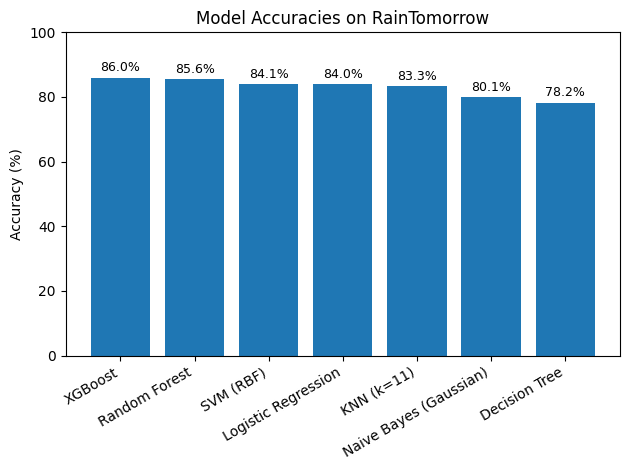

In [25]:
plt.bar(names_sorted, vals_sorted)
plt.ylabel("Accuracy (%)")
plt.title("Model Accuracies on RainTomorrow")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 100)
for i, v in enumerate(vals_sorted):
    plt.text(i, v + 1, f"{v:.1f}%", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

## Thank you...pls upvote!!!